In [1]:
from centrex_tlf import states, hamiltonian
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 14})

In [2]:
QN = states.generate_uncoupled_states_ground([0, 1, 2, 3, 4])
ham = hamiltonian.generate_uncoupled_hamiltonian_X(QN)
ham_func = hamiltonian.generate_uncoupled_hamiltonian_X_function(ham)

In [3]:
ham.Hff.shape

(100, 100)

In [4]:
import numpy as np
from scipy.optimize import linear_sum_assignment

Ez = np.linspace(0, 15, 51)

energies = np.zeros([len(Ez), len(QN)])
prev_vectors = None

for i, Ezi in enumerate(Ez):
    H = ham_func(np.array([0, 0, Ezi]), np.array([0, 0, 1e-5]))
    eigenvalues, eigenvectors = np.linalg.eigh(H)

    if prev_vectors is None:
        prev_vectors = eigenvectors
        energies[i] = eigenvalues
    else:
        cost = -np.abs(prev_vectors.conj().T @ eigenvectors)
        _, col_ind = linear_sum_assignment(cost)
        energies[i] = eigenvalues[col_ind]
        prev_vectors = eigenvectors[:, col_ind]
energies = energies / (2 * np.pi * 1e6)

In [5]:
H = ham_func(np.array([0, 0, 0]), np.array([0, 0, 1e-5]))
eigenvalues, eigenvectors = np.linalg.eigh(H)

states_uncoupled = hamiltonian.matrix_to_states(eigenvectors, QN)
states_uncoupled = [s.remove_small_components(1e-5) for s in states_uncoupled]
states_coupled = [s.transform_to_coupled().remove_small_components(1e-5) for s in states_uncoupled]

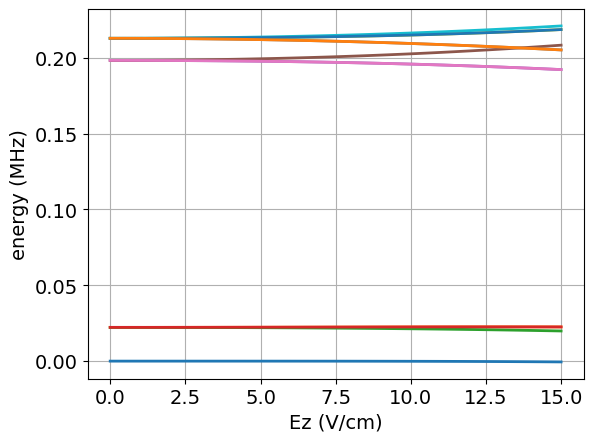

In [6]:
fig, ax = plt.subplots()
ax.plot(Ez, energies[:, 4:16] - energies[:, 4:16][0, 0], lw=2)
ax.set_xlabel("Ez (V/cm)")
ax.set_ylabel("energy (MHz)")
ax.grid()

Nothing weird specifically at 7-8 V/cm going on

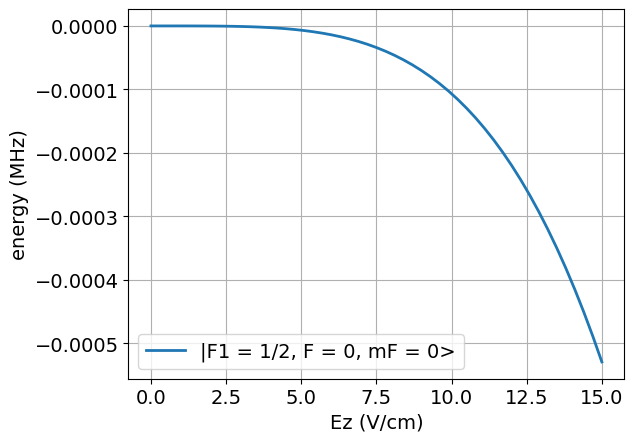

In [7]:
sl = slice(4, 5)
labels = [s.largest.state_string_custom(["F1", "F", "mF"]) for s in states_coupled[sl]]
fig, ax = plt.subplots()
ax.plot(Ez, energies[:, sl] - energies[:, sl][0, 0], lw=2, label=labels)
ax.set_xlabel("Ez (V/cm)")
ax.set_ylabel("energy (MHz)")
ax.legend()
ax.grid()

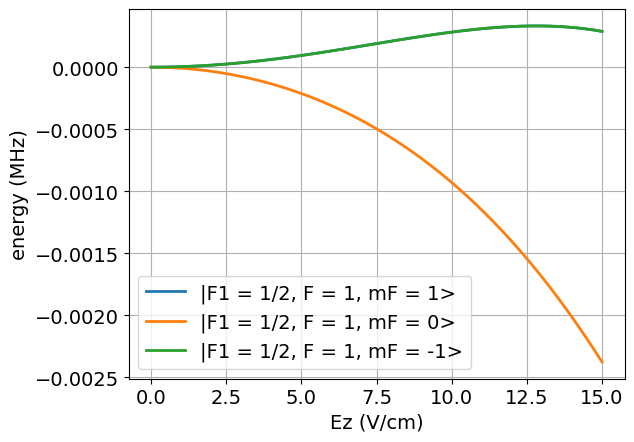

In [8]:
sl = slice(5, 8)
labels = [s.largest.state_string_custom(["F1", "F", "mF"]) for s in states_coupled[sl]]

fig, ax = plt.subplots()
ax.plot(Ez, energies[:, sl] - energies[:, sl][0, 0], lw=2, label=labels)
ax.set_xlabel("Ez (V/cm)")
ax.set_ylabel("energy (MHz)")
ax.legend()

ax.grid()

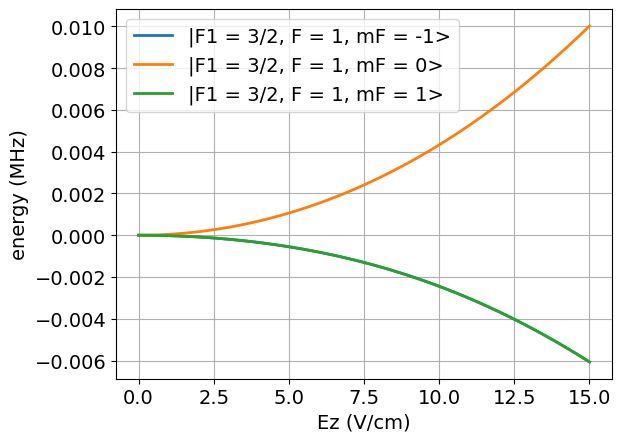

In [9]:
sl = slice(8, 11)
labels = [s.largest.state_string_custom(["F1", "F", "mF"]) for s in states_coupled[sl]]

fig, ax = plt.subplots()
ax.plot(Ez, energies[:, sl] - energies[:, sl][0, 0], lw=2, label=labels)
ax.set_xlabel("Ez (V/cm)")
ax.set_ylabel("energy (MHz)")
ax.legend()
ax.grid()

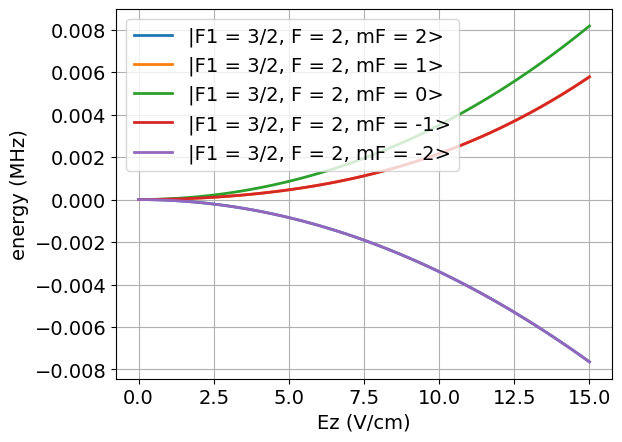

In [10]:
sl = slice(11, 16)
labels = [s.largest.state_string_custom(["F1", "F", "mF"]) for s in states_coupled[sl]]

fig, ax = plt.subplots()
ax.plot(Ez, energies[:, sl] - energies[:, sl][0, 0], lw=2, label=labels)
ax.set_xlabel("Ez (V/cm)")
ax.set_ylabel("energy (MHz)")
ax.legend()
ax.grid()